# VoiceBank Speech Enhancement: Dataset class and Preprocessing

**Project Goal**: Build a deep learning model to denoise speech using the VoiceBank-DEMAND dataset.

**Notebook Overview**:
-
- PyTorch Dataset class loading with caching
- Caching: persistent `.pkl` chunk cache to speed up reloading
- Extract and save log-Mel spectrograms from clean and noisy audio for faster training
- Model definition and training (next steps)

**Next Steps**:
- Define data loaders (`train_loader`, `val_loader`)
- Build and train the neural network model
- Evaluate and visualize performance

**Author**: Jo  
**Date**: Aug 2025


In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

In [2]:
import os
import torch
import librosa
import numpy as np
from torch.utils.data import Dataset
import glob
import pickle
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.signal import get_window
import sys


"""
# Set up paths
#data_root = "/content/voicebank_data"
#os.makedirs(data_root, exist_ok=True)

#drive_path = "/content/drive/MyDrive/SpeechData"


# Extract clean and noisy ZIPs
for zipname in ["clean_trainset_28spk_wav.zip", "noisy_trainset_28spk_wav.zip"]:
    zip_path = os.path.join(drive_path, zipname)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(os.path.join(data_root, zipname.replace(".zip", "")))
"""
data_root = "/kaggle/input/voicebank-demand"

In [3]:
tqdm(range(0, 4))

  0%|          | 0/4 [00:00<?, ?it/s]

In [4]:
!pip install torchaudio librosa soundfile matplotlib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 74.5 MB/s eta 0:00:00


## Dataset class

In [5]:

# from voicebank_dataset import VoiceBankDataset  # custom dataset class saved as .py file
sys.path.append("/kaggle/usr/lib/dataset_class")
from dataset_class import VoiceBankDataset

## Feature extraction
- Define feature extraction function
- Compute and save features
- Sample visualization

In [6]:
class FeatureExtractor_simple:
    """Enhanced feature extraction with multiple feature types"""
    
    def __init__(self, sr=16000, n_fft=512, hop_length=128, n_mels=64):
        self.sr = sr
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.n_mels = n_mels
        self.win_length = n_fft
        
    def extract_logmel(self, signal):
        """Extract log-mel spectrogram"""
        mel = librosa.feature.melspectrogram(
            y=signal,
            sr=self.sr,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            n_mels=self.n_mels,
            power=2.0,
            fmax=self.sr//2
        )
        mel_db = librosa.power_to_db(mel, ref=np.max, top_db=80)
        return mel_db.astype(np.float32)


In [7]:
class FeatureExtractor_multiple:
    """Feature extraction with multiple feature types"""
    
    def __init__(self, sr=16000, n_fft=512, hop_length=128, n_mels=64):
        self.sr = sr
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.n_mels = n_mels
        self.win_length = n_fft
        
    def extract_logmel(self, signal):
        """Extract log-mel spectrogram"""
        mel = librosa.feature.melspectrogram(
            y=signal,
            sr=self.sr,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            n_mels=self.n_mels,
            power=2.0,
            fmax=self.sr//2
        )
        mel_db = librosa.power_to_db(mel, ref=np.max, top_db=80)
        return mel_db.astype(np.float32)
    
    def extract_stft(self, signal):
        """Extract STFT magnitude and phase"""
        stft = librosa.stft(
            signal, 
            n_fft=self.n_fft, 
            hop_length=self.hop_length,
            win_length=self.win_length,
            window='hann'
        )
        magnitude = np.abs(stft)
        phase = np.angle(stft)
        
        # Convert to dB
        magnitude_db = librosa.amplitude_to_db(magnitude, ref=np.max, top_db=80)
        
        return magnitude_db.astype(np.float32), phase.astype(np.float32)
    
    def extract_mfcc(self, signal, n_mfcc=13):
        """Extract MFCC features"""
        mfcc = librosa.feature.mfcc(
            y=signal,
            sr=self.sr,
            n_mfcc=n_mfcc,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            n_mels=self.n_mels
        )
        return mfcc.astype(np.float32)
    
    def extract_spectral_features(self, signal):
        """Extract spectral features (centroid, bandwidth, rolloff)"""
        features = {}
        
        # Spectral centroid
        features['centroid'] = librosa.feature.spectral_centroid(
            y=signal, sr=self.sr, hop_length=self.hop_length
        )[0].astype(np.float32)
        
        # Spectral bandwidth
        features['bandwidth'] = librosa.feature.spectral_bandwidth(
            y=signal, sr=self.sr, hop_length=self.hop_length
        )[0].astype(np.float32)
        
        # Spectral rolloff
        features['rolloff'] = librosa.feature.spectral_rolloff(
            y=signal, sr=self.sr, hop_length=self.hop_length
        )[0].astype(np.float32)
        
        # Zero crossing rate
        features['zcr'] = librosa.feature.zero_crossing_rate(
            signal, hop_length=self.hop_length
        )[0].astype(np.float32)
        
        return features


In [8]:
def create_feature_directories(base_dir, feature_types):
    """Create directory structure for different feature types"""
    for feature_type in feature_types:
        for split in ['noisy', 'clean']:
            dir_path = os.path.join(base_dir, feature_type, split)
            os.makedirs(dir_path, exist_ok=True)
            print(f"Created directory: {dir_path}")



In [9]:
def extract_and_save_features(dataset, output_dir, feature_types=['logmel'], 
                             start_idx=0, end_idx=None, batch_size=100):
    """Extract and save all features with progress tracking"""
    if feature_types == ['logmel']:
        extractor = FeatureExtractor_simple(sr=dataset.sr)
    else:
        extractor = FeatureExtractor_multiple(sr=dataset.sr)
    
    if end_idx is None:
        end_idx = len(dataset)
    
    # Create directories
    create_feature_directories(output_dir, feature_types)
    
    # Statistics tracking
    stats = {ft: {'noisy': [], 'clean': []} for ft in feature_types}
    
    print(f"Extracting features from samples {start_idx} to {end_idx-1}")
    
    for idx in tqdm(range(start_idx, end_idx), desc="Processing samples"):
        try:
            # Get waveforms
            noisy_tensor, clean_tensor = dataset[idx]
            noisy_wave = noisy_tensor.squeeze().numpy()
            clean_wave = clean_tensor.squeeze().numpy()
            
            # Extract each feature type
            for feature_type in feature_types:
                
                if feature_type == 'logmel':
                    noisy_feat = extractor.extract_logmel(noisy_wave)
                    clean_feat = extractor.extract_logmel(clean_wave)
                    
                    # Add channel dimension: (n_mels, time) -> (1, n_mels, time)
                    noisy_feat = noisy_feat[np.newaxis, :, :]
                    clean_feat = clean_feat[np.newaxis, :, :]
                    
                elif feature_type == 'stft':
                    noisy_mag, noisy_phase = extractor.extract_stft(noisy_wave)
                    clean_mag, clean_phase = extractor.extract_stft(clean_wave)
                    
                    # Save magnitude and phase separately
                    noisy_feat = noisy_mag[np.newaxis, :, :]
                    clean_feat = clean_mag[np.newaxis, :, :]
                    
                    # Also save phase for reconstruction
                    np.save(f"{output_dir}/{feature_type}/noisy/sample_{idx}_phase.npy", 
                           noisy_phase[np.newaxis, :, :])
                    np.save(f"{output_dir}/{feature_type}/clean/sample_{idx}_phase.npy", 
                           clean_phase[np.newaxis, :, :])
                    
                elif feature_type == 'mfcc':
                    noisy_feat = extractor.extract_mfcc(noisy_wave)
                    clean_feat = extractor.extract_mfcc(clean_wave)
                    
                    # Add channel dimension
                    noisy_feat = noisy_feat[np.newaxis, :, :]
                    clean_feat = clean_feat[np.newaxis, :, :]
                
                # Save main features
                np.save(f"{output_dir}/{feature_type}/noisy/sample_{idx}.npy", noisy_feat)
                np.save(f"{output_dir}/{feature_type}/clean/sample_{idx}.npy", clean_feat)
                
                # Update statistics
                stats[feature_type]['noisy'].append({
                    'mean': np.mean(noisy_feat),
                    'std': np.std(noisy_feat),
                    'min': np.min(noisy_feat),
                    'max': np.max(noisy_feat)
                })
                stats[feature_type]['clean'].append({
                    'mean': np.mean(clean_feat),
                    'std': np.std(clean_feat),
                    'min': np.min(clean_feat),
                    'max': np.max(clean_feat)
                })
        
        except Exception as e:
            print(f"Error processing sample {idx}: {e}")
            continue
            
        # Save intermediate statistics every batch_size samples
        if (idx - start_idx + 1) % batch_size == 0:
            save_statistics(stats, output_dir, f"stats_batch_{idx//batch_size}.pkl")
    
    # Save final statistics
    save_statistics(stats, output_dir, "final_stats.pkl")
    print_feature_statistics(stats)
    
    return stats

In [10]:
def save_statistics(stats, output_dir, filename):
    """Save feature statistics"""
    stats_file = os.path.join(output_dir, filename)
    with open(stats_file, 'wb') as f:
        pickle.dump(stats, f)
        
def print_feature_statistics(stats):
    """Print feature statistics summary"""
    print("\nFeature Statistics Summary")
    print("=" * 60)
    
    for feature_type, data in stats.items():
        print(f"\n{feature_type.upper()} Features:")
        for split in ['noisy', 'clean']:
            if data[split]:
                means = [s['mean'] for s in data[split]]
                stds = [s['std'] for s in data[split]]
                
                print(f"  {split.capitalize()}:")
                print(f"    Mean: {np.mean(means):.4f} ± {np.std(means):.4f}")
                print(f"    Std:  {np.mean(stds):.4f} ± {np.std(stds):.4f}")


In [11]:
def visualize_features(output_dir, feature_types, sample_idx=0):
    """Visualize different feature representations"""
    
    n_features = len(feature_types)
    fig, axes = plt.subplots(n_features, 2, figsize=(15, 4*n_features))
    
    if n_features == 1:
        axes = axes.reshape(1, -1)
    
    for i, feature_type in enumerate(feature_types):
        # Load features
        noisy_path = f"{output_dir}/{feature_type}/noisy/sample_{sample_idx}.npy"
        clean_path = f"{output_dir}/{feature_type}/clean/sample_{sample_idx}.npy"
        
        if os.path.exists(noisy_path) and os.path.exists(clean_path):
            noisy_feat = np.squeeze(np.load(noisy_path))
            clean_feat = np.squeeze(np.load(clean_path))
            
            # Plot noisy
            im1 = axes[i, 0].imshow(noisy_feat, aspect='auto', origin='lower', 
                                  cmap='viridis')
            axes[i, 0].set_title(f'Noisy {feature_type.upper()}')
            axes[i, 0].set_xlabel('Time Frames')
            
            # Plot clean  
            im2 = axes[i, 1].imshow(clean_feat, aspect='auto', origin='lower', 
                                  cmap='viridis')
            axes[i, 1].set_title(f'Clean {feature_type.upper()}')
            axes[i, 1].set_xlabel('Time Frames')
            
            # Add colorbars
            plt.colorbar(im1, ax=axes[i, 0])
            plt.colorbar(im2, ax=axes[i, 1])
            
            # Set y-axis labels
            if feature_type == 'logmel':
                axes[i, 0].set_ylabel('Mel Bins')
                axes[i, 1].set_ylabel('Mel Bins')
            elif feature_type == 'stft':
                axes[i, 0].set_ylabel('Frequency Bins')
                axes[i, 1].set_ylabel('Frequency Bins')
            elif feature_type == 'mfcc':
                axes[i, 0].set_ylabel('MFCC Coefficients')
                axes[i, 1].set_ylabel('MFCC Coefficients')
    
    plt.tight_layout()
    plt.show()


In [12]:
def check_feature_consistency(output_dir, feature_types, num_samples=10):
    """Check feature extraction consistency and shapes"""
    print("\nChecking Feature Consistency")
    print("=" * 50)
    
    for feature_type in feature_types:
        print(f"\n{feature_type.upper()} Features:")
        
        shapes_noisy = []
        shapes_clean = []
        
        for i in range(num_samples):
            try:
                noisy_path = f"{output_dir}/{feature_type}/noisy/sample_{i}.npy"
                clean_path = f"{output_dir}/{feature_type}/clean/sample_{i}.npy"
                
                if os.path.exists(noisy_path) and os.path.exists(clean_path):
                    noisy_feat = np.load(noisy_path)
                    clean_feat = np.load(clean_path)
                    
                    shapes_noisy.append(noisy_feat.shape)
                    shapes_clean.append(clean_feat.shape)
            except Exception as e:
                print(f"Error loading sample {i}: {e}")
        
        if shapes_noisy and shapes_clean:
            print(f"  Sample shapes (first 5):")
            print(f"    Noisy: {shapes_noisy[:5]}")
            print(f"    Clean: {shapes_clean[:5]}")
            print(f"  Shape consistency: {len(set(shapes_noisy)) == 1 and len(set(shapes_clean)) == 1}")
            print(f"  Noisy-Clean match: {shapes_noisy == shapes_clean}")


## Parameters and dtaset loading
- Set up output directories
- Load datset

Starting Feature Extraction
Loading dataset...
Loaded 34765 cached chunks from /kaggle/input/voicebank-cache/voicebank_cache/chunks.pkl
Dataset loaded with 34765 samples

Extracting features for first 1000 samples...
Created directory: voicebank_features/logmel/noisy
Created directory: voicebank_features/logmel/clean
Extracting features from samples 0 to 999



Processing samples: 100%|██████████| 1000/1000 [00:24<00:00, 41.23it/s]



Feature Statistics Summary

LOGMEL Features:
  Noisy:
    Mean: -41.1384 ± 7.3742
    Std:  14.1583 ± 3.7182
  Clean:
    Mean: -53.9371 ± 7.9462
    Std:  19.3626 ± 1.8989

Checking Feature Consistency

LOGMEL Features:
  Sample shapes (first 5):
    Noisy: [(1, 64, 126), (1, 64, 126), (1, 64, 126), (1, 64, 126), (1, 64, 126)]
    Clean: [(1, 64, 126), (1, 64, 126), (1, 64, 126), (1, 64, 126), (1, 64, 126)]
  Shape consistency: True
  Noisy-Clean match: True

Visualizing features...


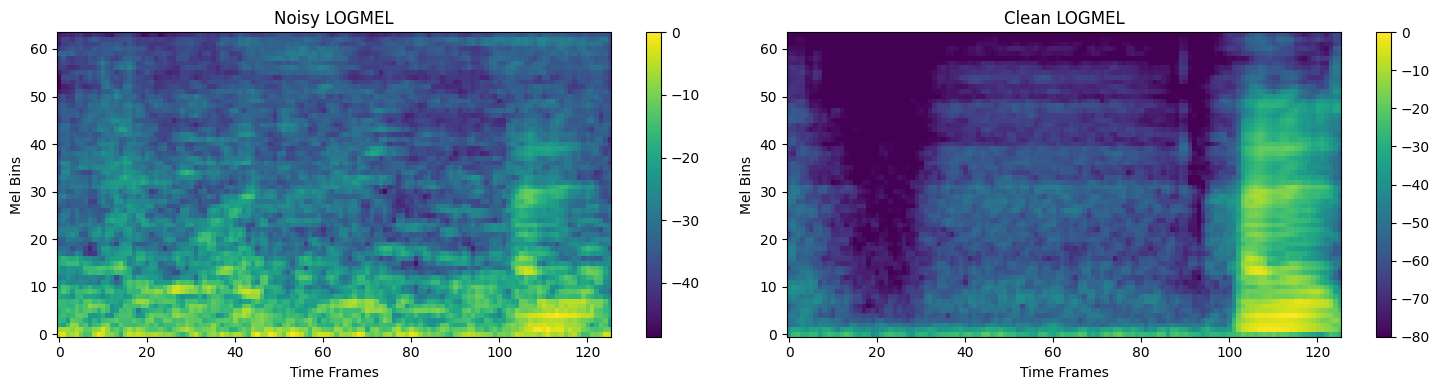


Feature comparison for sample 42:
  LOGMEL: (1, 64, 126) -> SNR improvement potential

Feature extraction complete!
Features saved to: voicebank_features
Directory structure:
  └── logmel/
      ├── noisy/
      └── clean/


In [13]:
if __name__ == "__main__":
    # Setup
    clean_dir = f"{data_root}/clean_trainset_28spk_wav"
    noisy_dir = f"{data_root}/noisy_trainset_28spk_wav"
    feature_output_dir = "voicebank_features"
    
    print("Starting Feature Extraction")
    
    # Load dataset (created in previous notebook)
    print("Loading dataset...")
    # persistent catching
    dataset = VoiceBankDataset(
        clean_dir=clean_dir,
        noisy_dir=noisy_dir,
        cache_dir="/kaggle/input/voicebank-cache/voicebank_cache/",
        use_cache=True,
        augment=False  # No augmentation for feature extraction
    )
  
    # lazy loading
    #dataset = VoiceBankDataset(clean_dir, noisy_dir,use_cache=False)
    print(f"Dataset loaded with {len(dataset)} samples")
    
    # Extract multiple feature types
    # feature_types = ['logmel', 'stft', 'mfcc']
    feature_types = ['logmel']
    
    # Extract features for a subset first (for testing)
    print("\nExtracting features for first 1000 samples...")
    
    stats = extract_and_save_features(
        dataset=dataset,
        output_dir=feature_output_dir,
        feature_types=feature_types,
        start_idx=0,
        end_idx=min(1000, len(dataset)),
        batch_size=100
    )
    
    # Check consistency
    check_feature_consistency(feature_output_dir, feature_types)
    
    # Visualize features
    print("\nVisualizing features...")
    visualize_features(feature_output_dir, feature_types, sample_idx=42)
    
    # Compare different feature representations
    print("\nFeature comparison for sample 42:")
    for ft in feature_types:
        noisy_feat = np.load(f"{feature_output_dir}/{ft}/noisy/sample_42.npy")
        clean_feat = np.load(f"{feature_output_dir}/{ft}/clean/sample_42.npy")
        print(f"  {ft.upper()}: {noisy_feat.shape} -> SNR improvement potential")
    
    print("\nFeature extraction complete!")
    print(f"Features saved to: {feature_output_dir}")
    print("Directory structure:")
    for ft in feature_types:
        print(f"  └── {ft}/")
        print(f"      ├── noisy/")
        print(f"      └── clean/")

All shapes identical (1, 64, 126) - No processing errors
Clean < Noisy means (-53.94 < -41.14) dB - Correct relationship, noisy signal has more energy
Good dynamic range (14-19 dB std) - good variation
Proper dB ranges (-40 to -60 dB) - Well-normalized spectrograms
